# PART 1: Systems of Linear Differential Equations (Pharmacokinetics)


--- Pharmacokinetics: Drug Absorption Model --- 

Enter initial drug dose in mg: 100
Enter absorption rate from stomach: 0.2
Enter elimination rate from body: 0.1
Enter hours to simulate: 48




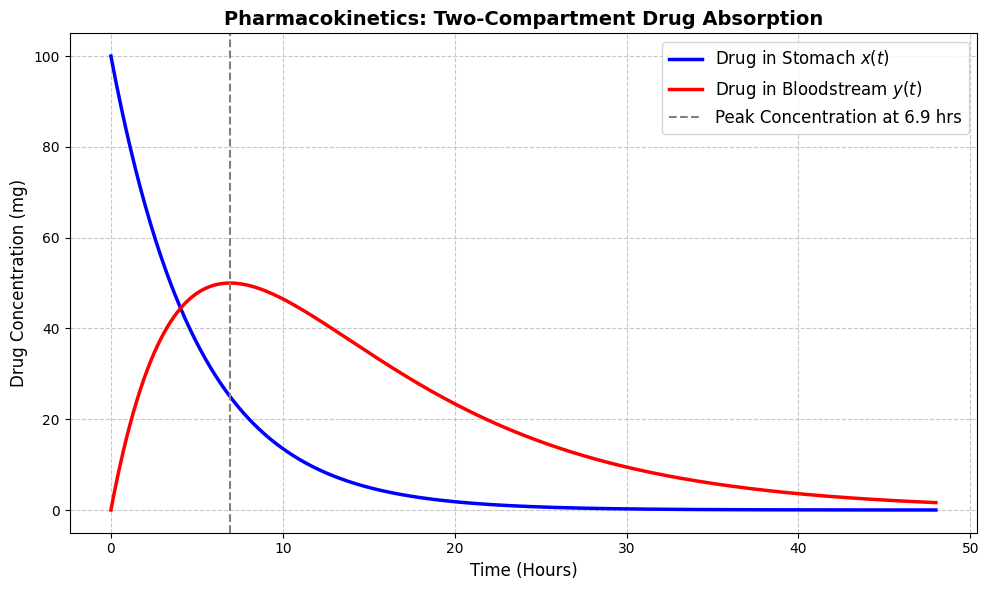

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Pharmacokinetics: Drug Absorption Model --- \n")
try:
  # User Inputs
    dose = float(input("Enter initial drug dose in mg: "))
    k_abs = float(input("Enter absorption rate from stomach: "))
    k_elim = float(input("Enter elimination rate from body: "))
    hours = int(input("Enter hours to simulate: "))
    print("\n")

# Time array
    t = np.linspace(0, hours, 500)

# x(t) = Drug in GI Tract (Stomach)
    x_t = dose * np.exp(-k_abs * t)

# y(t) = Drug in Target Organ/Bloodstream
# Formula derived using Integrating Factor method
    constant_C = (k_abs * dose) / (k_abs - k_elim)
    y_t = constant_C * (np.exp(-k_elim * t) - np.exp(-k_abs * t))

# Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(t, x_t, label='Drug in Stomach $x(t)$', color='blue', linewidth=2.5)
    plt.plot(t, y_t, label='Drug in Bloodstream $y(t)$', color='red', linewidth=2.5)

# Visual markers
    peak_time = t[np.argmax(y_t)]
    peak_amount = np.max(y_t)
    plt.axvline(x=peak_time, color='gray', linestyle='--', label=f'Peak Concentration at {peak_time:.1f} hrs')

    plt.title('Pharmacokinetics: Two-Compartment Drug Absorption', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Hours)', fontsize=12)
    plt.ylabel('Drug Concentration (mg)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except ValueError:
    print("Error: Please enter valid numbers.")
except ZeroDivisionError:
    print("Error: Absorption and elimination rates cannot be identical for this specific formula.")

# PART 2: Laplace Transforms - Car Suspension (Speed Bump)

--- Car Suspension (Laplace Transform) Model --- 

Enter car mass (m) in kg: 1
Enter damping coefficient (c): 2
Enter spring constant (k): 5
Enter speed bump impulse force (F0): 10
Enter simulation time in seconds: 10

--- Mathematical Output ---
Transfer Function Y(s) = 10.0/(1.0*s**2 + 2.0*s + 5.0)
Displacement Equation y(t) = 5.0*exp(-1.0*t)*sin(2.0*t)




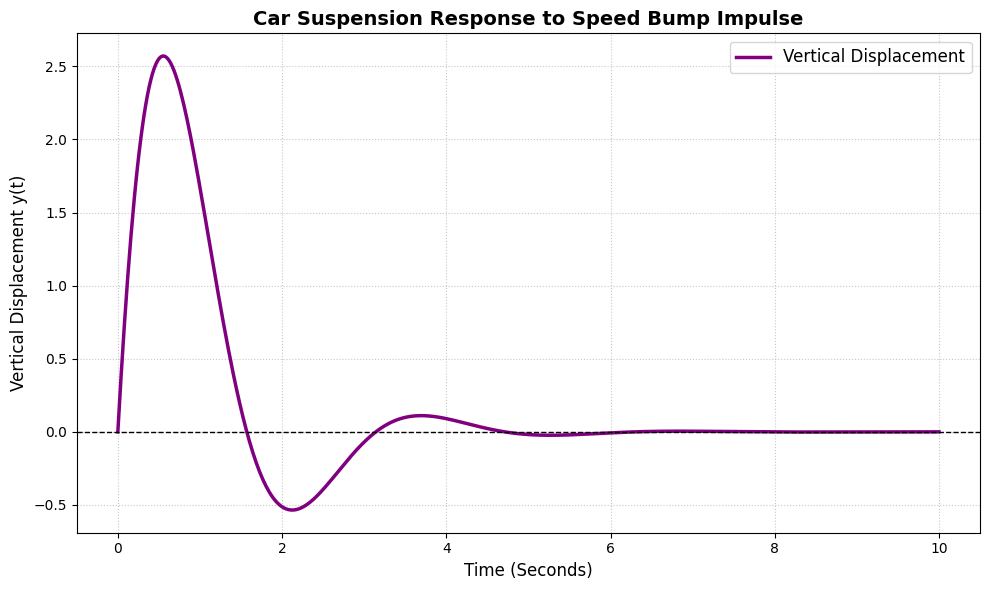

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

print("--- Car Suspension (Laplace Transform) Model --- \n")
try:
  # User inputs
    mass = float(input("Enter car mass (m) in kg: "))
    c_val = float(input("Enter damping coefficient (c): "))
    k_val = float(input("Enter spring constant (k): "))
    F0_val = float(input("Enter speed bump impulse force (F0): "))
    time_sim = float(input("Enter simulation time in seconds: "))

# Define Symbolic Variables for sympy
    s = sp.symbols('s')
    t = sp.symbols('t', real=True, positive=True)

# Laplace Domain Equation Y(s)
# The initial eqn is m*y'' + c*y' + k*y = F0*delta(t)
# With initial conditions y(0)=0, y'(0)=0, this becomes:
# (m*s^2 + c*s + k)*Y(s) = F0
    Y_s = F0_val / (mass * s**2 + c_val * s + k_val)

# Perform Inverse Laplace Transform
    y_t = sp.inverse_laplace_transform(Y_s, s, t)

    print("\n--- Mathematical Output ---")
    print(f"Transfer Function Y(s) = {Y_s}")
    print(f"Displacement Equation y(t) = {y_t}")
    print("\n")

# Converting Equation to a Numerical Function for Plotting
    y_func = sp.lambdify(t, y_t, modules=['numpy'])

# Generating Data Points and Plot
    t_vals = np.linspace(0, time_sim, 500)
    y_vals = y_func(t_vals)

    plt.figure(figsize=(10, 6))
    plt.plot(t_vals, y_vals, color='purple', linewidth=2.5, label='Vertical Displacement')
    plt.axhline(0, color='black', linestyle='--', linewidth=1) # Equilibrium line

    plt.title('Car Suspension Response to Speed Bump Impulse', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Seconds)', fontsize=12)
    plt.ylabel('Vertical Displacement y(t)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

except ValueError:
    print("Error: Please enter valid numerical values.")

# Systems of ODEs (The SIR Model)

--- SIR Epidemiological Model Generator --- 

Enter total population: 1000
Enter initial number of infected people: 5
Enter transmission rate (beta): 0.3
Enter recovery rate (gamma): 0.1
Enter number of days to simulate: 160
Enter lockdown start day: 20


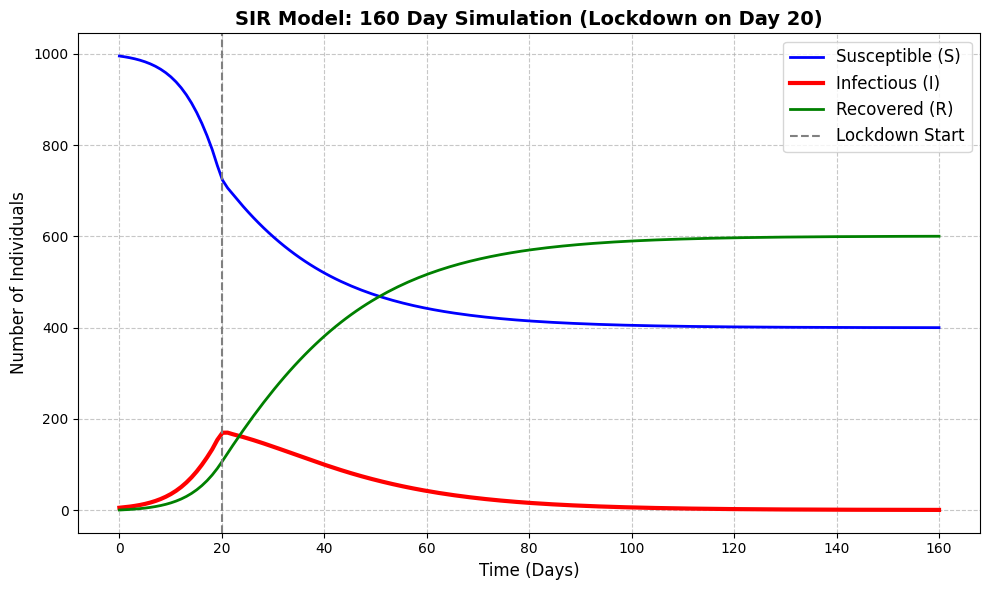

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def sir_model(t, y, beta, gamma, lockdown_day):
    S, I, R = y

    if t >= lockdown_day:
        current_beta = beta * 0.4 #60% reduction in transmitting
    else:
        current_beta = beta

    dS_dt = -current_beta*S*I
    dI_dt = current_beta * S * I - gamma * I
    dR_dt = gamma * I
    return [dS_dt, dI_dt, dR_dt]

print("--- SIR Epidemiological Model Generator --- \n")
try:
    N = int(input("Enter total population: "))
    I0 = int(input("Enter initial number of infected people: "))
    beta_input = float(input("Enter transmission rate: "))
    gamma = float(input("Enter recovery rate: "))
    days = int(input("Enter number of days to simulate: "))
    lockdown_day = int(input("Enter lockdown start day: "))
    print("\n")

    # Setup Initial Conditions
    R0 = 0
    S0 = N - I0 - R0
    beta = beta_input / N

    t_span = (0, days) #start & end; time duration
    t_eval = np.linspace(t_span[0], t_span[1], days) #(start, stop, number_of_points) i.e. how many snaps to take to plot graph

    # Solving
    solution = solve_ivp(sir_model, t_span, [S0, I0, R0], args=(beta, gamma, lockdown_day), t_eval=t_eval)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(solution.t, solution.y[0], label='Susceptible (S)', color='blue', linewidth=2)
    plt.plot(solution.t, solution.y[1], label='Infectious (I)', color='red', linewidth=3) # Made 'I' thicker to see the peak
    plt.plot(solution.t, solution.y[2], label='Recovered (R)', color='green', linewidth=2)

    # Added a vertical line to show exactly when lockdown started
    plt.axvline(x=lockdown_day, color='gray', linestyle='--', label='Lockdown Start')

    plt.title(f'SIR Model: {days} Day Simulation (Lockdown on Day {lockdown_day})', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Days)', fontsize=12)
    plt.ylabel('Number of Individuals', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except ValueError:
    print("Error: Please enter valid numbers.")